# E1 213 Pattern Recognition and Neural Network - Assignment 2
***
*Submitted by: Dwaipayan Haldar*<br>
*S.R. No. : 27128*

In [1]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
from torch import nn
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_curve
device = "mps" if torch.mps.is_available() else "cpu"

from src import *

In [16]:
model = OwnVanillaRNN(1,32,1)
matrix = model.linearh.weight
singular_values = torch.linalg.svd(matrix)

singular_values.S[0].item()

1.1002849340438843

### **Phase 1**: The MLP Baseline and Gradient Flow

In [10]:
DATA_DIR = '/Users/dwaipayanhaldar/Downloads/Notes and Books/IISc Coding Assignments and Project/Data/PRNN_2026_A2_data'
time_series_file_path = os.path.join(DATA_DIR, 'delhi_aqi.csv')

data_regression = TimeSeriesDataset(time_series_file_path, 72,24, all_features= True)
data_classify = TimeSeriesDataset(time_series_file_path, 72,24, all_features = True, classify=True)

#### **Problem 1.1**: Flattened Temporal MLP(Regression)

In [8]:
torch.manual_seed(25)
torch.mps.manual_seed(25)

N = len(data_regression)
train_end = int(0.7*N)
val_end = int(0.85*N)

X_train = Subset(data_regression, range(0, train_end))
X_val = Subset(data_regression, range(train_end, val_end))
X_test = Subset(data_regression, range(val_end, N))


train_loader = DataLoader(X_train, batch_size=32, shuffle=False)
val_loader = DataLoader(X_val, batch_size=32, shuffle=False)
test_loader = DataLoader(X_test, batch_size=32, shuffle=False)

model = Temporal_MLP(input_dim= data_regression.input_dim).to(device)
    
learning_rate = 1e-3
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
epochs = 100
    
train_loop(train_loader, val_loader, model, loss_fn, optimizer, epochs, patience=10)
test_loop(test_loader, model, loss_fn)

Epoch 0: Training Loss: 46146.5625, Validation Loss: 12646.1541
Epoch 10: Training Loss: 37427.9961, Validation Loss: 12977.6079
Early stopping at epoch 10. Best Validation Loss: 12646.1541
Test Loss (MSE): 73866.0763


#### **Problem 1.2**: Vanishing Gradient Proof 

Epoch 0: Training Loss: 113543.3047, Validation Loss: 22806.8728


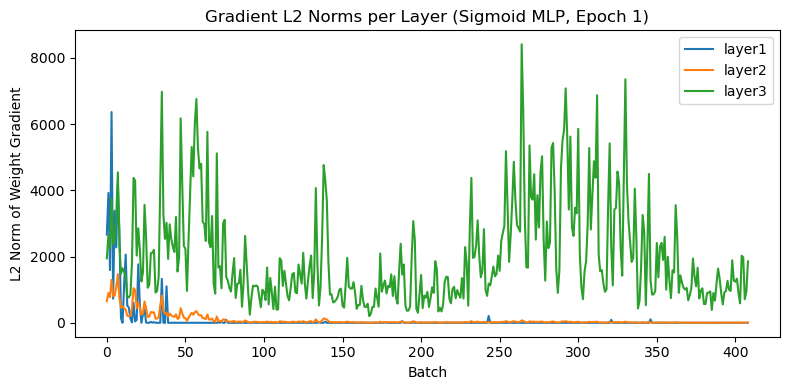

In [9]:
torch.manual_seed(25)
torch.mps.manual_seed(25)

sigmoid_model = Temporal_MLP(input_dim= data_regression.input_dim, sigmoid=True).to(device)
sigmoid_optimizer = torch.optim.Adam(sigmoid_model.parameters(), lr=learning_rate)

grad_norms = train_loop(train_loader, val_loader, sigmoid_model, loss_fn,                           sigmoid_optimizer, epochs, patience=10, backward_hook=True)

batches = range(len(grad_norms['layer1']))
plt.figure(figsize=(8, 4))
for layer_name, norms in grad_norms.items():
    plt.plot(norms, label=layer_name)
plt.xlabel('Batch')
plt.ylabel('L2 Norm of Weight Gradient')
plt.title('Gradient L2 Norms per Layer (Sigmoid MLP, Epoch 1)')
plt.legend()
plt.tight_layout()
plt.savefig('gradient_flow_sigmoid.png', dpi=150)
plt.show()

#### **Problem 1.3**: Imbalanced Threshold Classification 

Epoch 0: Training Loss: 58.6835, Validation Loss: 86.6201
Epoch 10: Training Loss: 58.7149, Validation Loss: 86.6201
Early stopping at epoch 10. Best Validation Loss: 86.6201
Standard BCE:
[[   0 1006]
 [   0 1796]]
Epoch 0: Training Loss: 18.4323, Validation Loss: 1.0351
Epoch 10: Training Loss: 0.8164, Validation Loss: 0.7325
Early stopping at epoch 12. Best Validation Loss: 0.6122
Weighted BCE:
[[ 975   31]
 [1753   43]]


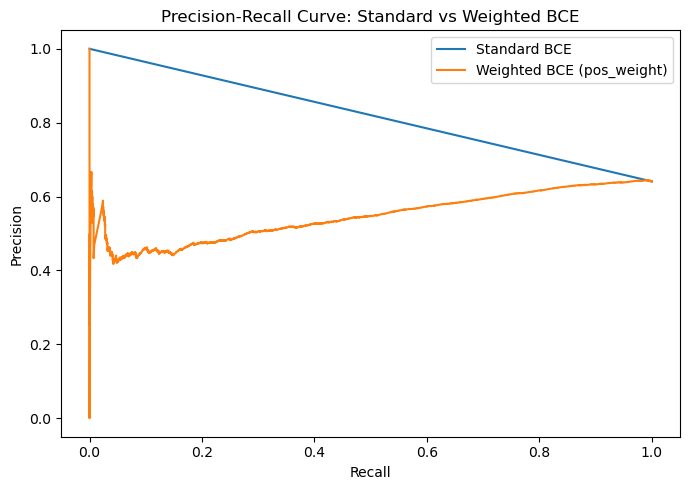

In [15]:
torch.manual_seed(0)
torch.mps.manual_seed(0)

N = len(data_classify)

train_end = int(0.7*N)
val_end = int(0.85*N)

X_train_classify = Subset(data_classify, range(0, train_end))
X_val_classify = Subset(data_classify, range(train_end, val_end))
X_test_classify = Subset(data_classify, range(val_end, N))

train_loader_clasify = DataLoader(X_train_classify, batch_size=32, shuffle=False)
val_loader_clasify = DataLoader(X_val_classify, batch_size=32, shuffle=False)
test_loader_clasify = DataLoader(X_test_classify, batch_size=32, shuffle=False)

n_neg = sum(1 for _, y in X_train_classify if y == 0)
n_pos = sum(1 for _, y in X_train_classify if y == 1)
pos_weight = torch.tensor([n_neg / n_pos]).to(device)

learning_rate = 1e-3
epochs = 100

model_std = Temporal_MLP(input_dim= data_classify.input_dim,classify=True).to(device)
loss_fn_std = nn.BCELoss()
optimizer_std = torch.optim.Adam(model_std.parameters(), lr=learning_rate)
train_loop(train_loader_clasify, val_loader_clasify, model_std, loss_fn_std, optimizer_std, epochs)
print("Standard BCE:")
probs_std, y_true = test_loop(test_loader_clasify, model_std, loss_fn_std, classify=True)


model_weighted = Temporal_MLP(input_dim=data_classify.input_dim).to(device)
loss_fn_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_weighted = torch.optim.Adam(model_weighted.parameters(), lr=learning_rate)
train_loop(train_loader_clasify, val_loader_clasify, model_weighted, loss_fn_weighted, optimizer_weighted, epochs)
print("Weighted BCE:")
probs_weighted, _ = test_loop(test_loader_clasify, model_weighted, loss_fn_weighted, classify=True, Logit_loss=True)


prec_std, rec_std, _ = precision_recall_curve(y_true, probs_std)
prec_w, rec_w, _ = precision_recall_curve(y_true, probs_weighted)
plt.figure(figsize=(7, 5))
plt.plot(rec_std, prec_std, label='Standard BCE')
plt.plot(rec_w,   prec_w,   label='Weighted BCE (pos_weight)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Standard vs Weighted BCE')
plt.legend()
plt.tight_layout()
plt.savefig('pr_curve_1_3.png', dpi=150)
plt.show()